In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(
    "international-visitors-london.csv",
    encoding="cp1252"
)

In [38]:
numeric_columns = [
    "Visits (000s)",
    "Spend (£m)",
    "Nights (000s)",
    "sample"
]

In [22]:
df.head

<bound method NDFrame.head of         year        quarter        market     dur_stay mode        purpose  \
0       2002  January-March       Belgium  1-3  nights  Air        Holiday   
1       2002  January-March       Belgium  1-3  nights  Air       Business   
2       2002  January-March       Belgium  1-3  nights  Air            VFR   
3       2002  January-March       Belgium  1-3  nights  Air  Miscellaneous   
4       2002  January-March       Belgium  1-3  nights  Sea       Business   
...      ...            ...           ...          ...  ...            ...   
61457  2020P  January-March  Other Africa  4-7  nights  Air  Miscellaneous   
61458  2020P  January-March  Other Africa  8-14 nights  Air        Holiday   
61459  2020P  January-March  Other Africa  8-14 nights  Air            VFR   
61460  2020P  January-March  Other Africa  15+  nights  Air        Holiday   
61461  2020P  January-March  Other Africa  15+  nights  Air            VFR   

          area  Visits (000s)  Sp

In [18]:
df.shape

(61462, 11)

In [19]:
df.columns

Index(['year', 'quarter', 'market', 'dur_stay', 'mode', 'purpose', 'area',
       'Visits (000s)', 'Spend (£m)', 'Nights (000s)', 'sample'],
      dtype='object')

In [20]:
df.dtypes

year              object
quarter           object
market            object
dur_stay          object
mode              object
purpose           object
area              object
Visits (000s)    float64
Spend (£m)       float64
Nights (000s)    float64
sample             int64
dtype: object

DATA PREPARATION 

Unique Values

In [89]:
def display_unique_summary(df, columns):
    missing_columns = [
        column for column in columns
        if column not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Columns not found in DataFrame: {missing_columns}"
        )

    for column in columns:
        unique_values = (
            df[column]
            .dropna()
            .drop_duplicates()
            .tolist()
        )

        unique_count = len(unique_values)

        print(f"{column}:")
        print(f"Unique values: {unique_count}")

        if unique_count <= 10:
            print(", ".join(map(str, unique_values)))
        else:
            print(", ".join(map(str, unique_values[:5])))
            print("...")
            print(", ".join(map(str, unique_values[-5:])))

        print("-" * 50)

    return None


display_unique_summary(
    df,
    columns=["dur_stay", "mode", "quarter", "area", "market"]
)

dur_stay:
Unique values: 4
1-3  nights, 4-7  nights, 8-14 nights, 15+  nights
--------------------------------------------------
mode:
Unique values: 3
Air, Sea, Tunnel
--------------------------------------------------
quarter:
Unique values: 4
January-March, April-June, July-September, October-December
--------------------------------------------------
area:
Unique values: 1
 LONDON
--------------------------------------------------
market:
Unique values: 62
Belgium, Luxembourg, France, Germany, Italy
...
Chile, Indonesia, Bahrain, Oman, Qatar
--------------------------------------------------


Missing Values

In [21]:
df.isnull().sum()

year             0
quarter          0
market           0
dur_stay         0
mode             0
purpose          0
area             0
Visits (000s)    0
Spend (£m)       0
Nights (000s)    0
sample           0
dtype: int64

Unexpected Values

In [43]:
for column in numeric_columns:
    converted_values = pd.to_numeric(df[column], errors="coerce")

    strange_mask = df[column].notna() & converted_values.isna()

    print(f"\nColumn: {column}")
    print(f"Current data type: {df[column].dtype}")
    print(f"Number of strange values: {strange_mask.sum()}")

    if strange_mask.sum() > 0:
        print("Strange values:")
        print(df.loc[strange_mask, column].value_counts().head(20))


Column: Visits (000s)
Current data type: float64
Number of strange values: 0

Column: Spend (£m)
Current data type: float64
Number of strange values: 0

Column: Nights (000s)
Current data type: float64
Number of strange values: 0

Column: sample
Current data type: int64
Number of strange values: 0


In [53]:
for column in numeric_columns:
    strange_symbols = (
        df[column]
        .astype(str)
        .str.contains(r"[^0-9.,\-\s]", regex=True, na=False)
    )

    print(f"\n{column}: {strange_symbols.sum()} values with unusual symbols")

    if strange_symbols.any():
        print(df.loc[strange_symbols, column].value_counts().head(20))


Visits (000s): 0 values with unusual symbols

Spend (£m): 3 values with unusual symbols
Spend (£m)
0.000072    1
0.000057    1
0.000006    1
Name: count, dtype: int64

Nights (000s): 0 values with unusual symbols

sample: 0 values with unusual symbols


Outliers

In [39]:
for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(f"\nColumn: {column}")
    print(f"Lower bound: {lower_bound:.2f}")
    print(f"Upper bound: {upper_bound:.2f}")
    print(f"Number of outliers: {len(outliers)}")


Column: Visits (000s)
Lower bound: -4.57
Upper bound: 9.81
Number of outliers: 7054

Column: Spend (£m)
Lower bound: -3.71
Upper bound: 7.04
Number of outliers: 6274

Column: Nights (000s)
Lower bound: -34.47
Upper bound: 67.86
Number of outliers: 6757

Column: sample
Lower bound: -5.00
Upper bound: 11.00
Number of outliers: 6994


In [30]:
df.nlargest(20, "Spend (£m)")[
    [
        "year",
        "quarter",
        "market",
        "purpose",
        "Visits (000s)",
        "Spend (£m)",
        "Nights (000s)",
        "sample"
    ]
]

,year,quarter,market,purpose,Visits (000s),Spend (£m),Nights (000s),sample
28397,2010,April-June,Mexico,Holiday,7.290278,373.232590,20.387059,5
53969,2017,July-September,Saudi Arabia,Holiday,25.175373,313.081236,279.743915,26
53975,2017,July-September,Saudi Arabia,VFR,5.777371,277.357109,351.472595,4
55977,2018,April-June,USA,Holiday,142.202996,196.159302,732.787979,146
51225,2016,October-December,USA,Business,80.345259,177.243672,369.025526,86
56743,2018,July-September,USA,Holiday,182.477796,163.517932,928.712715,148
53656,2017,July-September,USA,Holiday,113.790236,162.923637,792.765753,125
24994,2009,April-June,Japan,Holiday,9.621325,155.645995,20.061919,18
55254,2018,January-March,USA,Business,107.121247,145.103330,487.949356,106
49456,2016,April-June,USA,Business,79.664955,139.922257,354.560301,129


DATA ANALISYS

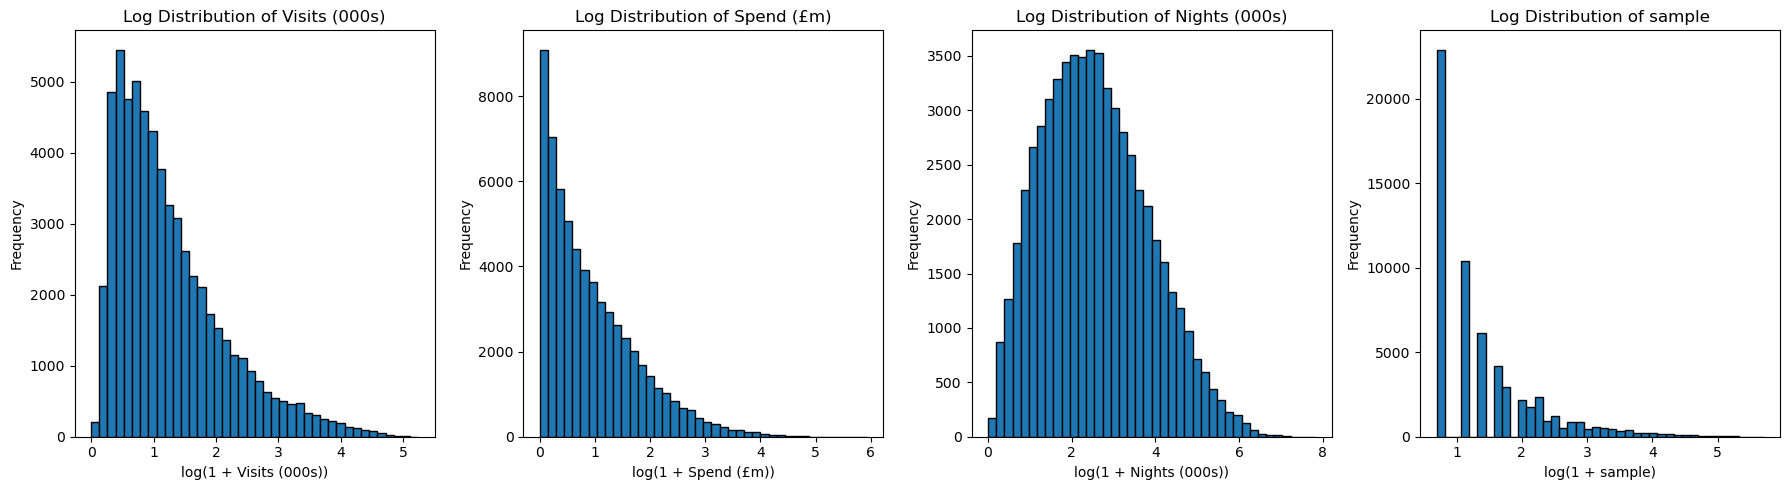

In [63]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(numeric_columns),
    figsize=(18, 5)
)

for ax, column in zip(axes, numeric_columns):
    values = df[column].dropna()
    ax.hist(np.log1p(values), bins=40, edgecolor="black")

    ax.set_title(f"Log Distribution of {column}")
    ax.set_xlabel(f"log(1 + {column})")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [67]:
def analyse_markets(df):

    market_summary = (
        df.groupby("market", as_index=False)
        .agg(
            average_spend=("Spend (£m)", "mean"),
            average_nights=("Nights (000s)", "mean")
        )
        .sort_values("average_spend", ascending=False)
        .reset_index(drop=True)
    )

    print(f"Number of unique markets: {df['market'].nunique()}")

    return market_summary
market_summary = analyse_markets(df)

market_summary

Number of unique markets: 62


,market,average_spend,average_nights
0,USA,12.519774,95.728161
1,Italy,6.325103,77.398662
2,China,5.705772,37.429786
3,Spain,5.474436,67.816007
4,Kuwait,5.254016,23.806234
...,...,...,...
57,Czech Republic,0.883779,14.366306
58,Luxembourg,0.809467,5.998693
59,Kenya,0.756650,10.007355
60,Other Southern Africa,0.701890,11.404194
